In [26]:
# first train/get a pretrianed model and covert it to an array
import torch
import numpy as np
from ultralytics import YOLO
from PIL import Image
import cv2
import matplotlib.pyplot as plt

model = YOLO("yolov5n.pt")
state_dict = model.model.state_dict()

# convert model
weights = {k.replace(".", "_"): v.cpu().numpy() for k, v in state_dict.items()}

# visualize the weights and structure
for name, array in weights.items():
    print(f"Layer: {name}")
    print(f"  Shape: {array.shape}")
    print(f"  Dtype: {array.dtype}")
    # Print first 5 elements flat
    print(f"  Sample values: {array.flatten()[:5]}")
    print("-" * 40)

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Layer: model_0_conv_weight
  Shape: (16, 3, 6, 6)
  Dtype: float32
  Sample values: [ -0.0069771    0.041779  -0.0025826  0.00072384   0.0033131]
----------------------------------------
Layer: model_0_bn_weight
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.9062      2.0273      5.5508       1.041      3.7422]
----------------------------------------
Layer: model_0_bn_bias
  Shape: (16,)
  Dtype: float32
  Sample values: [     1.5957      1.5889      -6.457      4.3125     -5.7539]
----------------------------------------
Layer: model_0_bn_running_mean
  Shape: (16,)
  Dtype: float32
  Sample values: [  -0.019547  -0.0048332    -0.47876     0.13147     0.42725]
----------------------------------------
Layer: model_0_bn_run

## Inference >>>

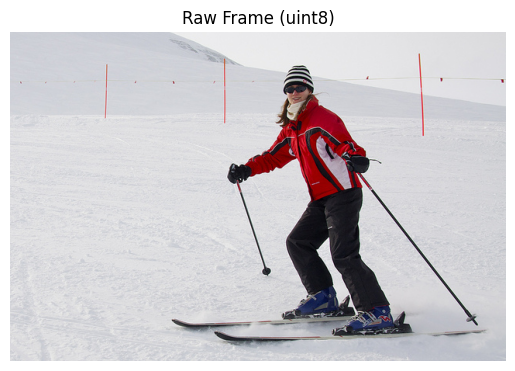

In [27]:
weights = weights
frame = Image.open("/mnt/fileserver/prj/yolo-inference-from-scratch/imgs/000000000785.jpg")
frame = np.array(frame)

# visualize
plt.imshow(frame)  # HWC, RGB
plt.title("Raw Frame (uint8)")
plt.axis("off")
plt.show()

### 1. Pre process img/vid (frame)

  Shape: (3, 640, 640)
  Dtype: float32


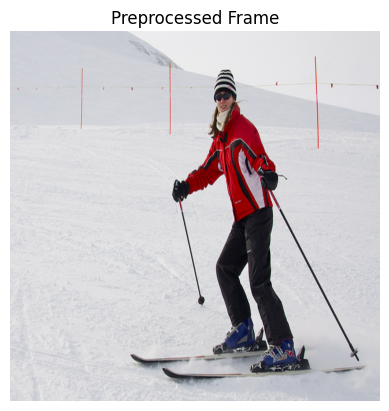

In [28]:
# 1.1. downscale
res = "640*640" #320*320

if res == "320*320":
    imsz = (640,640)
else:   # default
    imsz = (640,640)

frame = cv2.resize(frame, imsz)

# 1.2. convert frame to np.arrays unit8->float32,float16,int8
d_type = "fp32"

if d_type == "fp16":
    frame = frame.astype(np.float16)
elif d_type == "int8":
    frame = (frame*255).astype(np.int8)
else: # default
    frame = frame.astype(np.float32)

# 1.3. Normalize to [0,1]
frame = frame/255

# 1.4 Convert from HWC to CHW
frame = np.transpose(frame, (2, 0, 1))

# visualize (convert back to HWC)
print(f"  Shape: {frame.shape}")
print(f"  Dtype: {frame.dtype}")
frame_to_show = frame.transpose(1, 2, 0)
plt.imshow(frame_to_show)
plt.title("Preprocessed Frame")
plt.axis("off")
plt.show()

In [29]:
# # Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# # Parameters
# nc: 80 # number of classes
# depth_multiple: 0.33 # model depth multiple
# width_multiple: 0.25 # layer channel multiple
# anchors:
#   - [10, 13, 16, 30, 33, 23] # P3/8
#   - [30, 61, 62, 45, 59, 119] # P4/16
#   - [116, 90, 156, 198, 373, 326] # P5/32

# # YOLOv5 v6.0 backbone
# backbone:
#   # [from, number, module, args]
#   [
#     [-1, 1, Conv, [64, 6, 2, 2]], # 0-P1/2
#     [-1, 1, Conv, [128, 3, 2]], # 1-P2/4
#     [-1, 3, C3, [128]],
#     [-1, 1, Conv, [256, 3, 2]], # 3-P3/8
#     [-1, 6, C3, [256]],
#     [-1, 1, Conv, [512, 3, 2]], # 5-P4/16
#     [-1, 9, C3, [512]],
#     [-1, 1, Conv, [1024, 3, 2]], # 7-P5/32
#     [-1, 3, C3, [1024]],
#     [-1, 1, SPPF, [1024, 5]], # 9
#   ]

# # YOLOv5 v6.0 head
# head: [
#     [-1, 1, Conv, [512, 1, 1]],
#     [-1, 1, nn.Upsample, [None, 2, "nearest"]],
#     [[-1, 6], 1, Concat, [1]], # cat backbone P4
#     [-1, 3, C3, [512, False]], # 13

#     [-1, 1, Conv, [256, 1, 1]],
#     [-1, 1, nn.Upsample, [None, 2, "nearest"]],
#     [[-1, 4], 1, Concat, [1]], # cat backbone P3
#     [-1, 3, C3, [256, False]], # 17 (P3/8-small)

#     [-1, 1, Conv, [256, 3, 2]],
#     [[-1, 14], 1, Concat, [1]], # cat head P4
#     [-1, 3, C3, [512, False]], # 20 (P4/16-medium)

#     [-1, 1, Conv, [512, 3, 2]],
#     [[-1, 10], 1, Concat, [1]], # cat head P5
#     [-1, 3, C3, [1024, False]], # 23 (P5/32-large)

#     [[17, 20, 23], 1, Detect, [nc, anchors]], # Detect(P3, P4, P5)
#   ]

### 2. Forward Pass

for each layer
1. conv
2. batch norm
3. SiLU activation

In [30]:
import numpy as np

def im2col(x, kH, kW, stride=1, padding=0):
    x = x.astype(np.float32)
    C, H, W = x.shape
    if padding > 0:
        x = np.pad(x, ((0,0),(padding,padding),(padding,padding)), mode='constant', constant_values=0)
    
    H_out = (H + 2*padding - kH)//stride + 1
    W_out = (W + 2*padding - kW)//stride + 1
    cols = np.zeros((C * kH * kW, H_out * W_out), dtype=np.float32)

    col_idx = 0
    for y in range(0, H_out*stride, stride):
        for x_ in range(0, W_out*stride, stride):
            patch = x[:, y:y+kH, x_:x_+kW]
            cols[:, col_idx] = patch.reshape(-1)
            col_idx += 1

    return cols

def conv2d_forward(x, w, stride=1, padding=0):
    x = x.astype(np.float32)
    w = w.astype(np.float32)
    C_out, C_in, kH, kW = w.shape
    H_out = (x.shape[1] + 2*padding - kH)//stride + 1
    W_out = (x.shape[2] + 2*padding - kW)//stride + 1

    x_col = im2col(x, kH, kW, stride, padding)
    w_col = w.reshape(C_out, -1)

    out = w_col @ x_col
    out = out.reshape(C_out, H_out, W_out)
    return out.astype(np.float32)

def batchnorm_forward(x, gamma, beta, running_mean, running_var, eps=1e-3):
    x = x.astype(np.float32)
    gamma = gamma.astype(np.float32)
    beta = beta.astype(np.float32)
    running_mean = running_mean.astype(np.float32)
    running_var = running_var.astype(np.float32)

    x_hat = (x - running_mean[:, None, None]) / np.sqrt(running_var[:, None, None] + eps)
    out = gamma[:, None, None] * x_hat + beta[:, None, None]
    return out.astype(np.float32)

def silu(x):
    return (x * (1 / (1 + np.exp(-np.clip(x, -50, 50))))).astype(np.float32)

def CBL_forward(x, conv_w, bn_gamma, bn_beta, bn_mean, bn_var, stride=1, padding=0):
    out = conv2d_forward(x, conv_w, stride=stride, padding=padding)
    out = batchnorm_forward(out, bn_gamma, bn_beta, bn_mean, bn_var)
    out = silu(out)
    return out

In [31]:
depth_multiple= 0.33 # model depth multiple
width_multiple= 0.25 # layer channel multiple

Layer definition: [-1, 1, 'Conv', [64, 6, 2, 2]]
From: -1
Repeat (depth scaled): 1
Kernel: 6
Stride: 2
Padding: 2
Channels original: 64
Channels scaled: 16

Input layer: 0
Shape: (3, 640, 640)
Dtype: float32

Output layer: 0
Shape: (16, 320, 320)
Expected channels: 16
Dtype: float32

Expected job: detect edges, color grads, texture primitives, corners


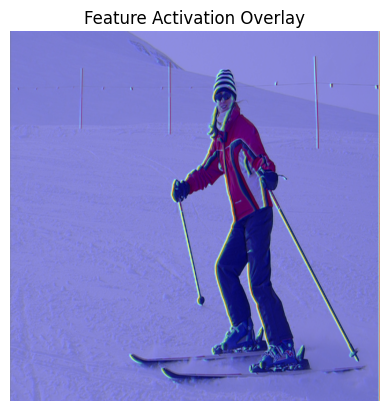

In [32]:
# [from, number, module, args]
layer_def = [-1, 1, "Conv", [64, 6, 2, 2]]  # 0-P1/2
from_idx, number, _, args = layer_def
out_channels, kernel, stride, padding = args
repeat = max(round(number * depth_multiple), 1)
scaled_channels = int(out_channels * width_multiple)

print("Layer definition:", layer_def)
print("From:", from_idx)
print("Repeat (depth scaled):", repeat)
print("Kernel:", kernel)
print("Stride:", stride)
print("Padding:", padding)
print("Channels original:", out_channels)
print("Channels scaled:", scaled_channels)

# Layer0
job = "detect edges, color grads, texture primitives, corners"
layer = 0

# input
layer0_in = frame
print(f"\nInput layer: {layer}")
print(f"Shape: {layer0_in.shape}")
print(f"Dtype: {layer0_in.dtype}")

# weights
conv_w   = weights["model_0_conv_weight"]
bn_gamma = weights["model_0_bn_weight"]
bn_beta  = weights["model_0_bn_bias"]
bn_mean  = weights["model_0_bn_running_mean"]
bn_var   = weights["model_0_bn_running_var"]


# output
layer0_out = CBL_forward(
    layer0_in,
    conv_w,
    bn_gamma,
    bn_beta,
    bn_mean,
    bn_var,
    stride=stride,
    padding=padding
)

print(f"\nOutput layer: {layer}")
print(f"Shape: {layer0_out.shape}")
print(f"Expected channels: {scaled_channels}")
print(f"Dtype: {layer0_out.dtype}")

print("\nExpected job:", job)

# visualize first feature map
heatmap = layer0_out[0]
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
heatmap = cv2.resize(heatmap, (640,640))

plt.imshow(frame_to_show)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("Feature Activation Overlay")
plt.show()

Layer definition: [-1, 1, 'Conv', [128, 3, 2, 1]]
From: -1
Repeat (depth scaled): 1
Kernel: 3
Stride: 2
Padding: 1
Channels original: 128
Channels scaled: 32

Input layer: 1
Shape: (16, 320, 320)
Dtype: float32

Output layer: 1
Shape: (32, 160, 160)
Expected channels: 32
Dtype: float32

Expected job: downsample, feature extraction, preparing for deeper layers


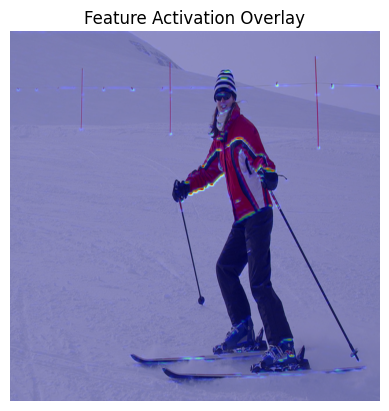

In [33]:
# [from, number, module, args]
layer_def = [-1, 1, "Conv", [128, 3, 2, 1]]
from_idx, number, _, args = layer_def
out_channels, kernel, stride, padding = args
repeat = max(round(number * depth_multiple), 1)
scaled_channels = int(out_channels * width_multiple)

print("Layer definition:", layer_def)
print("From:", from_idx)
print("Repeat (depth scaled):", repeat)
print("Kernel:", kernel)
print("Stride:", stride)
print("Padding:", padding)
print("Channels original:", out_channels)
print("Channels scaled:", scaled_channels)

# Layer1
job = "downsample, feature extraction, preparing for deeper layers"
layer = 1

# input
layer1_in = layer0_out
print(f"\nInput layer: {layer}")
print(f"Shape: {layer1_in.shape}")
print(f"Dtype: {layer1_in.dtype}")

# weights
conv_w   = weights["model_1_conv_weight"]
bn_gamma = weights["model_1_bn_weight"]
bn_beta  = weights["model_1_bn_bias"]
bn_mean  = weights["model_1_bn_running_mean"]
bn_var   = weights["model_1_bn_running_var"]

# output
layer1_out = CBL_forward(
    layer1_in,
    conv_w,
    bn_gamma,
    bn_beta,
    bn_mean,
    bn_var,
    stride=stride,
    padding=padding
)

print(f"\nOutput layer: {layer}")
print(f"Shape: {layer1_out.shape}")
print(f"Expected channels: {scaled_channels}")
print(f"Dtype: {layer1_out.dtype}")

print("\nExpected job:", job)

# visualize first feature map
heatmap = layer1_out[0]
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())
heatmap = cv2.resize(heatmap, (640,640))

plt.imshow(frame_to_show)
plt.imshow(heatmap, cmap="jet", alpha=0.4)
plt.axis("off")
plt.title("Feature Activation Overlay")
plt.show()